In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings(action='ignore')

import quant

In [2]:
CONFIG_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "lseg-data.config.json"
VIX_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "data" / "vix.csv"
session = quant.SessionProvider(CONFIG_PATH)

In [3]:
START = datetime(1997, 1, 18)
END = datetime(2026, 1, 17)

In [4]:
with session as client:
    bonds = client.bonds.list_securities("Altria Group Inc")
    stocks = client.equities.list_securities("Altria Group Inc")

In [5]:
for bond in bonds:
    print(f"{bond.name} ({bond.ric})")

print("#" * 20)
    
for stock in stocks:
    print(f"{stock.name} ({stock.ric})")


Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 2.625 16-Sep-2026 (02209SAU7=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 7.75 15-Jan-2027 (718154CF2=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, MO 2.2 15-Jun-2027 (US184344319=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.875 04-Feb-2028 (02209SBS1=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 6.2 01-Nov-2028 (02209SBQ5=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.8 14-Feb-2029 (02209SBD4=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 3.4 06-May-2030 (02209SBJ1=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.5 06-Aug-2030 (02209SBU6=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, MO 3.125 15-Jun-2031 (US184344378=)
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 2.45 04-Feb-2032 (02209SBL6=)
Altria Group Inc, Plain Vanilla Fixed 

In [6]:
RIC_STOCK = 'MO'
common_stock_l1 = next(filter(lambda stock: stock.ric == RIC_STOCK, stocks))
common_stock_l1

EquityL1(name='Altria Group Inc, Ordinary Share, NYSE Consolidated', ric='MO', perm_id='55839269969', pi='1097565', business_entity='QUOTExEQUITY')

In [7]:
with session as client:
    historical_iv = client.equities.historical_iv(
        "MO", 
        interval=quant.Interval.DAY_1,
        start=START,
        end=END,
    )

In [8]:
vix = pd.read_csv(VIX_PATH, sep='\t', parse_dates=True, index_col=0).rename(columns={"Close": "VIX_Close"})

vix = vix[(START < vix.index) & (vix.index < END)]

vix

,VIX_Close
Date,
1997-01-20,18.60
1997-01-21,17.81
1997-01-22,17.09
1997-01-23,18.47
1997-01-24,19.33
...,...
2026-01-12,15.12
2026-01-13,15.98
2026-01-14,16.75


In [9]:
EQUITIES_FIELDS = [
        "BID",
        "ASK",
        "TR.CompanyMarketCap",
        "TR.H.PriceToBVPerShare",
        "TR.F.NetDebt",                                                        
        "TR.F.NetCashFlowOp",
        "TR.F.STDebtCurrPortOfLTDebt",
        "TR.F.DebtLTTot",
        "TR.F.EBITDA",
        "TR.F.TotAssets",
]

with session as client:
    common_stock_df = client.equities.history_df(common_stock_l1, fields=EQUITIES_FIELDS,
                                                        interval=quant.Interval.DAY_1,
                                                        start=START,
                                                        end=END,
                                                    )
        
    common_stock_df = common_stock_df.ffill().rename(columns={"BID": "MO_Bid", "ASK": "MO_Ask"})

In [10]:
from itertools import islice

def batched(iterable, n):
    it = iter(iterable)
    while chunk := list(islice(it, n)):
        yield chunk

with session as client:
    bond_df = pd.concat([
        client.bonds.history_df(batch, fields=[
            "TR.ZSPREAD",
            "TR.OPTIONADJUSTEDSPREADBID",
            "TR.MODIFIEDDURATION",
            "TR.CONVEXITY",
            "TR.BASISPOINTVALUE",
            "TR.INTERPOLATEDGOVERNMENTSPREAD",
        ],
        interval=quant.Interval.DAY_1,
        start=START,
        end=END,
        )
        for batch in batched(bonds, 3)
    ])

In [11]:
bond_df

02209SAU7=                                                         \
             Z Spread Option Adjusted Spread Bid Modified Duration Convexity   
Date                                                                           
2019-02-12        NaN                        NaN               NaN       NaN   
2019-02-13        NaN                        NaN               NaN       NaN   
2019-02-14        NaN                        NaN               NaN       NaN   
2019-02-15        NaN                        NaN               NaN       NaN   
2019-02-18        NaN                        NaN               NaN       NaN   
...               ...                        ...               ...       ...   
2026-01-12        NaN                        NaN               NaN       NaN   
2026-01-13        NaN                        NaN               NaN       NaN   
2026-01-14        NaN                        NaN               NaN       NaN   
2026-01-15        NaN                        NaN               NaN       NaN   
2026-01-16        NaN                        NaN               NaN       NaN   

                                                            718154CF2=  \
           Basis Point Value Interpolated Government Spread   Z Spread   
Date                                                                     
2019-02-12               NaN                            NaN        NaN   
2019-02-13               NaN                            NaN        NaN   
2019-02-14               NaN                            NaN        NaN   
2019-02-15               NaN                            NaN        NaN   
2019-02-18               NaN                            NaN        NaN   
...                      ...                            ...        ...   
2026-01-12               NaN                            NaN        NaN   
2026-01-13               NaN                            NaN        NaN   
2026-01-14               NaN                            NaN        NaN   
2026-01-15               NaN                            NaN        NaN   
2026-01-16               NaN                            NaN        NaN   

                                                                   ...  \
           Option Adjusted Spread Bid Modified Duration Convexity  ...   
Date                                                               ...   
2019-02-12                        NaN               NaN       NaN  ...   
2019-02-13                        NaN               NaN       NaN  ...   
2019-02-14                        NaN               NaN       NaN  ...   
2019-02-15                        NaN               NaN       NaN  ...   
2019-02-18                        NaN               NaN       NaN  ...   
...                               ...               ...       ...  ...   
2026-01-12                        NaN               NaN       NaN  ...   
2026-01-13                        NaN               NaN       NaN  ...   
2026-01-14                        NaN               NaN       NaN  ...   
2026-01-15                        NaN               NaN       NaN  ...   
2026-01-16                        NaN               NaN       NaN  ...   

                  02209SAQ6=                              \
           Modified Duration Convexity Basis Point Value   
Date                                                       
2019-02-12              <NA>      <NA>              <NA>   
2019-02-13              <NA>      <NA>              <NA>   
2019-02-14              <NA>      <NA>              <NA>   
2019-02-15              <NA>      <NA>              <NA>   
2019-02-18              <NA>      <NA>              <NA>   
...                      ...       ...               ...   
2026-01-12           11.2889   168.864            9.7781   
2026-01-13           11.2853   168.782             9.774   
2026-01-14           11.3005  169.1017            9.8366   
2026-01-15           11.2981  169.0457            9.8369   
2026-01-16           11.2681  168.38

In [12]:
for x in bond_df.columns:
    print(x)

('02209SAU7=', 'Z Spread')
('02209SAU7=', 'Option Adjusted Spread Bid')
('02209SAU7=', 'Modified Duration')
('02209SAU7=', 'Convexity')
('02209SAU7=', 'Basis Point Value')
('02209SAU7=', 'Interpolated Government Spread')
('718154CF2=', 'Z Spread')
('718154CF2=', 'Option Adjusted Spread Bid')
('718154CF2=', 'Modified Duration')
('718154CF2=', 'Convexity')
('718154CF2=', 'Basis Point Value')
('718154CF2=', 'Interpolated Government Spread')
('US184344319=', 'Z Spread')
('US184344319=', 'Option Adjusted Spread Bid')
('US184344319=', 'Modified Duration')
('US184344319=', 'Convexity')
('US184344319=', 'Basis Point Value')
('US184344319=', 'Interpolated Government Spread')
('02209SBS1=', 'Z Spread')
('02209SBS1=', 'Option Adjusted Spread Bid')
('02209SBS1=', 'Modified Duration')
('02209SBS1=', 'Convexity')
('02209SBS1=', 'Basis Point Value')
('02209SBS1=', 'Interpolated Government Spread')
('02209SBQ5=', 'Z Spread')
('02209SBQ5=', 'Option Adjusted Spread Bid')
('02209SBQ5=', 'Modified Duratio

In [13]:
working_dfs = {}

with session as client:
    for bond_l1 in tqdm(bonds):
        bond = bond_df[bond_l1.ric].dropna()
        
        bond = bond.ffill()
        
        working_df = vix.join(common_stock_df).join(bond).join(historical_iv.df).dropna()

        working_df = working_df[~working_df.index.duplicated(keep='first')]

        eq_value = working_df["Company Market Cap"]
        eq_vol = ((working_df["MO_Bid"] + working_df["MO_Ask"]) / 2.0).pct_change().rolling(60, min_periods=20).std() * (252 ** 0.5)
        common_idx = eq_value.index.intersection(eq_vol.index)

        panel = pd.DataFrame({
            "equity_value":      eq_value,
            "equity_volatility": eq_vol,
            "short_term_debt":   working_df["Short-Term Debt & Current Portion of Long-Term Debt"],
            "long_term_debt":    working_df["Debt - Long-Term - Total"],
            "z_spread":          working_df["Z Spread"].mean()
        }, index=common_idx).dropna()

        # panel = panel[(panel["equity_volatility"] > 0) & 
        #             (panel["equity_value"] > 0) & 
        #             (panel["short_term_debt"] + panel["long_term_debt"] > 0)]

        risk_free_rate_decimal = 0.045

        base_inputs = quant.kmv.KMVInputs(
            equity_value=1.0, 
            equity_volatility=0.1, 
            short_term_debt=1.0, 
            long_term_debt=1.0, 
            risk_free_rate=risk_free_rate_decimal
        )
        
        if panel.shape[0] == 0:
            print("skipping bad data returned from LSEG")
            continue            

        ts = quant.kmv_timeseries.build_from_panel(panel, base_inputs=base_inputs, name="Altria Group (MO)")
        
        working_df_dd = working_df.join(ts.dd_series()).join(ts.basis_series()).join(ts.edf_series()).dropna()
        
        working_dfs[bond_l1.ric] = working_df_dd

  0%|          | 0/20 [00:00<?, ?it/s]

skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG


 60%|██████    | 12/20 [00:03<00:02,  3.35it/s]

skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG
skipping bad data returned from LSEG


100%|██████████| 20/20 [00:06<00:00,  3.16it/s]


In [14]:
len(working_dfs)

8

In [16]:
ric_to_bond = {bond.ric: bond for bond in bonds}

In [35]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit

bond_to_pred_power = {}

for idx, df in working_dfs.items():
    df = df.dropna()
    
    mo_log_move = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5).dropna())
    vix_log_move = np.log(df['VIX_Close'].shift(-30).clip(lower=5)) - np.log(df['VIX_Close'].clip(lower=5).dropna())
    df['target_residual'] = mo_log_move - vix_log_move

    # DD Velocity: Is the firm moving toward or away from the default boundary?
    df['dd_velocity_21d'] = df['dd'].diff(21)
    df['dd_velocity_5d'] = df['dd'].diff(5)

    df['term_structure_30_90'] = df['30D_A_IM_P'] - df['90D_A_IM_P']
    df['term_structure_30_60'] = df['30D_A_IM_P'] - df['60D_A_IM_P']

    # Velocity of Volatility
    df['vol_30d_velocity'] = df['30D_A_IM_P'].diff(5) 

    # Relative Volatility (How jumpy is it relative to the average?)
    df['vol_zscore'] = (df['30D_A_IM_P'] - df['30D_A_IM_P'].rolling(252).mean()) / df['30D_A_IM_P'].rolling(252).std()

    # Leverage Ratio: Standard credit anchor
    df['leverage_ratio'] = df['Net Debt'] / df['Earnings before Interest Taxes Depreciation & Amortization'].replace(0, np.nan)
    df['leverage_velocity_63d'] = df['leverage_ratio'].diff(63) # Quarterly change trend

    df['asset_cushion'] = df['Total Assets'] / (df['Short-Term Debt & Current Portion of Long-Term Debt'] + df['Debt - Long-Term - Total']).replace(0, np.nan)

    df['dts'] = df['Modified Duration'] * df['Z Spread']


    # VIX Z-Score: Market panic relative to the last year
    df['vix_rolling_mean'] = df['VIX_Close'].rolling(window=252).mean()
    df['vix_rolling_std'] = df['VIX_Close'].rolling(window=252).std()
    df['vix_zscore'] = (df['VIX_Close'] - df['vix_rolling_mean']) / df['vix_rolling_std'].replace(0, np.nan)

    # Negative Equity Regime Flag; Important for Altria's 2026 data where P/B is negative
    df['is_negative_equity'] = (df['Price To Book Value Per Share(Time Series Ratio)'] < 0).astype(int)

    df['dd_x_neg_equity'] = df['dd'] * df['is_negative_equity']

    # Drop the intermediate rolling columns used for Z-score
    df = df.drop(columns=['vix_rolling_mean', 'vix_rolling_std'])

    # List of finalized features for the model
    feature_cols = [
        'dd', 'dd_velocity_21d', 'term_structure_30_90', 'term_structure_30_60', 'vol_30d_velocity', 'vol_zscore',
        'leverage_ratio', 'leverage_velocity_63d', 'asset_cushion',
        'dts', 'vix_zscore', 'is_negative_equity', 'Convexity', 'dd_x_neg_equity'
    ]
    
    # 1. Target Definition & Data Alignment (Handling the 30-day NA shift)
    # We create the boolean mask first, then align it with our features
    y_raw = (df['target_residual'] > 0) 
    
    # print(df)
    
    # Drop NaNs from features (X) and then reindex the target (y) to match
    X = df[feature_cols].dropna() 
    y = y_raw.reindex(X.index).dropna().astype(int)
    
    # Final check: Ensure X only contains rows that have a valid target
    X = X.reindex(y.index)

    if len(X) <= 5: 
        print(f"{ric_to_bond[idx].name}")
        print(f"Skipping iteration: DataFrame is empty or too small after cleaning.")
        print("-" * 30)
        continue

    # 2. Time Series Split Setup
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    # Helper for Time-Decay Weights (Higher importance for recent 2025-2026 data)
    def get_decay_weights(n, decay_rate=0.005):
        w = np.exp(decay_rate * np.arange(n))
        return w / w.mean()

    # 3. Cross-Validation Training Loop
    for train_idx, test_idx in tscv.split(X):
        # Embargo: Purge the 30 rows prior to the test set to avoid leakage
        train_idx_purged = train_idx[:-30]
        
        X_train, X_test = X.iloc[train_idx_purged], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx_purged], y.iloc[test_idx]
        
        # Calculate weights for the training set
        weights = get_decay_weights(len(X_train))
        
        # Define and Fit Model
        model = XGBClassifier(
            n_estimators=150,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
        
        model.fit(X_train, y_train, sample_weight=weights)
        
        # Evaluate Directional Hit Rate
        preds = model.predict(X_test)
        scores.append(accuracy_score(y_test, preds))

    bond_to_pred_power[idx] = scores

    # 4. Output Results for the current DataFrame
    print(f"{ric_to_bond[idx].name}")
    print(f"\tValidated Hit Rates (Weighted) across 5 folds: {['{:.2%}'.format(s) for s in scores]}")
    print(f"\tAverage Hit Rate: {np.mean(scores):.2%}")
    print("-" * 30)

Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 3.4 06-May-2030
	Validated Hit Rates (Weighted) across 5 folds: ['64.86%', '43.24%', '62.70%', '41.08%', '50.81%']
	Average Hit Rate: 52.54%
------------------------------
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.5 06-Aug-2030
Skipping iteration: DataFrame is empty or too small after cleaning.
------------------------------
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, MO 3.125 15-Jun-2031
	Validated Hit Rates (Weighted) across 5 folds: ['57.56%', '62.18%', '60.08%', '30.25%', '54.62%']
	Average Hit Rate: 52.94%
------------------------------
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 2.45 04-Feb-2032
	Validated Hit Rates (Weighted) across 5 folds: ['34.42%', '61.04%', '72.08%', '62.34%', '51.30%']
	Average Hit Rate: 56.23%
------------------------------
Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 6.875 01-Nov-2033
	Validated Hit Rat

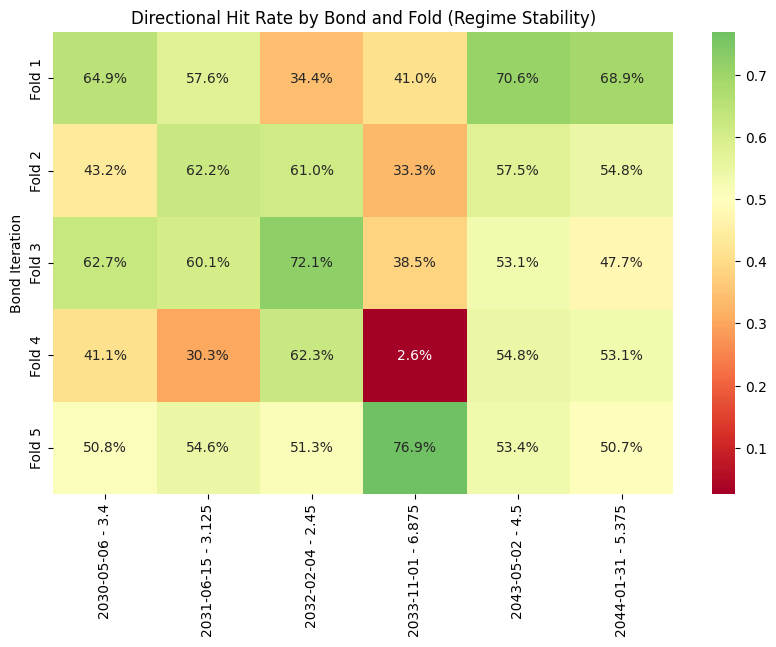

In [17]:
df_results = pd.DataFrame.from_dict(
    {f'{ric_to_bond[bond].maturity()} - {ric_to_bond[bond].coupon()}': bond_to_pred_power[bond] 
     for bond in working_dfs.keys() 
     if bond in bond_to_pred_power},
    orient='columns'
)
df_results.index = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_results, annot=True, fmt=".1%", cmap="RdYlGn", center=0.5)
plt.title("Directional Hit Rate by Bond and Fold (Regime Stability)")
plt.ylabel("Bond Iteration")
plt.show()

In [30]:
data = []
for ric, folds in bond_to_pred_power.items():
    for i, score in enumerate(folds):
        data.append({'RIC': ric, 'Fold': f'Fold {i+1}', 'Hit Rate': score})

df_plot = pd.DataFrame(data)

# Calculate summary stats for sorting
stats = df_plot.groupby('RIC')['Hit Rate'].agg(['mean', 'std']).sort_values('mean', ascending=False)

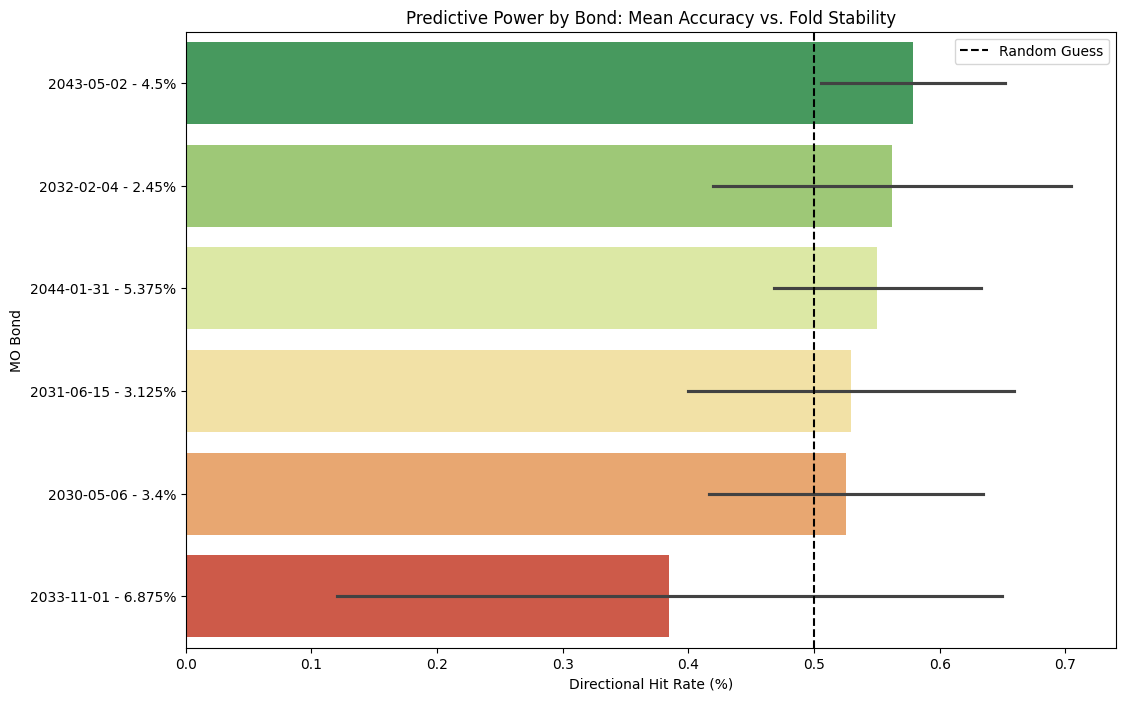

In [32]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_plot,
    x='Hit Rate',
    y='RIC',
    order=stats.index,
    palette='RdYlGn_r',
    errorbar='sd'
)


ax.set_yticklabels([f'{ric_to_bond[label.get_text()].maturity()} - {ric_to_bond[label.get_text()].coupon()}%' for label in ax.get_yticklabels()])

plt.axvline(0.5, color='black', linestyle='--', label='Random Guess')
plt.title("Predictive Power by Bond: Mean Accuracy vs. Fold Stability")
plt.xlabel("Directional Hit Rate (%)")
plt.ylabel("MO Bond")
plt.legend()
plt.show()

Best bond    Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 4.5 02-May-2043  (02209SAQ6=)
Mean hit     57.87%
Fold scores  ['70.57%', '57.49%', '53.13%', '54.77%', '53.41%']
Final model fitted on full history.


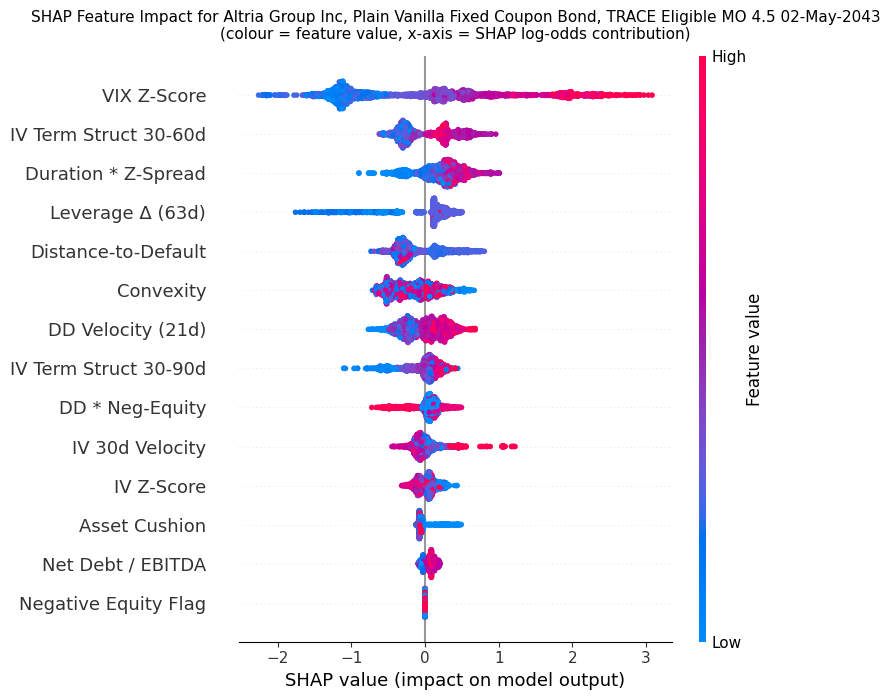

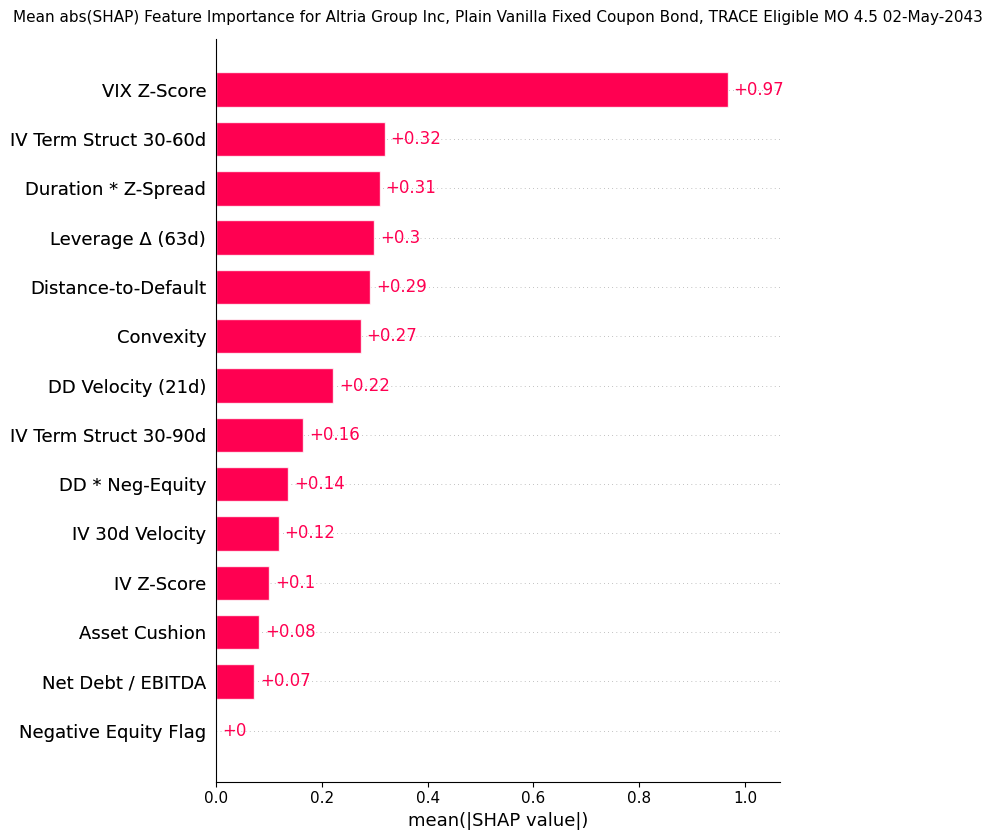

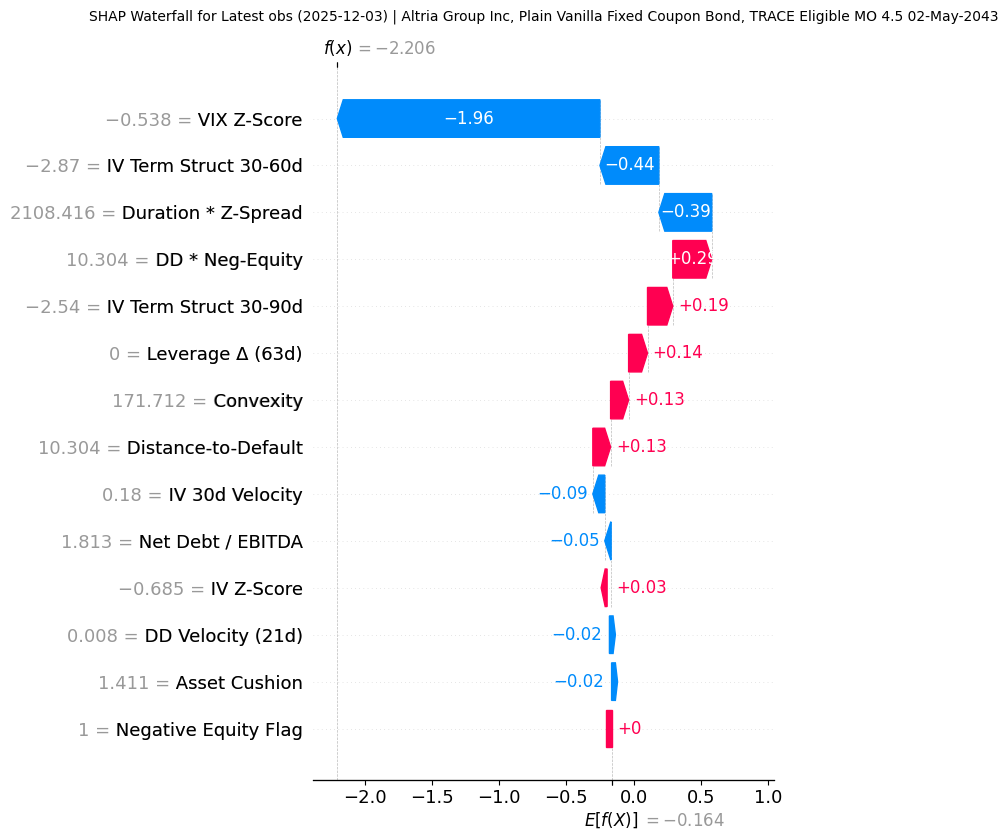

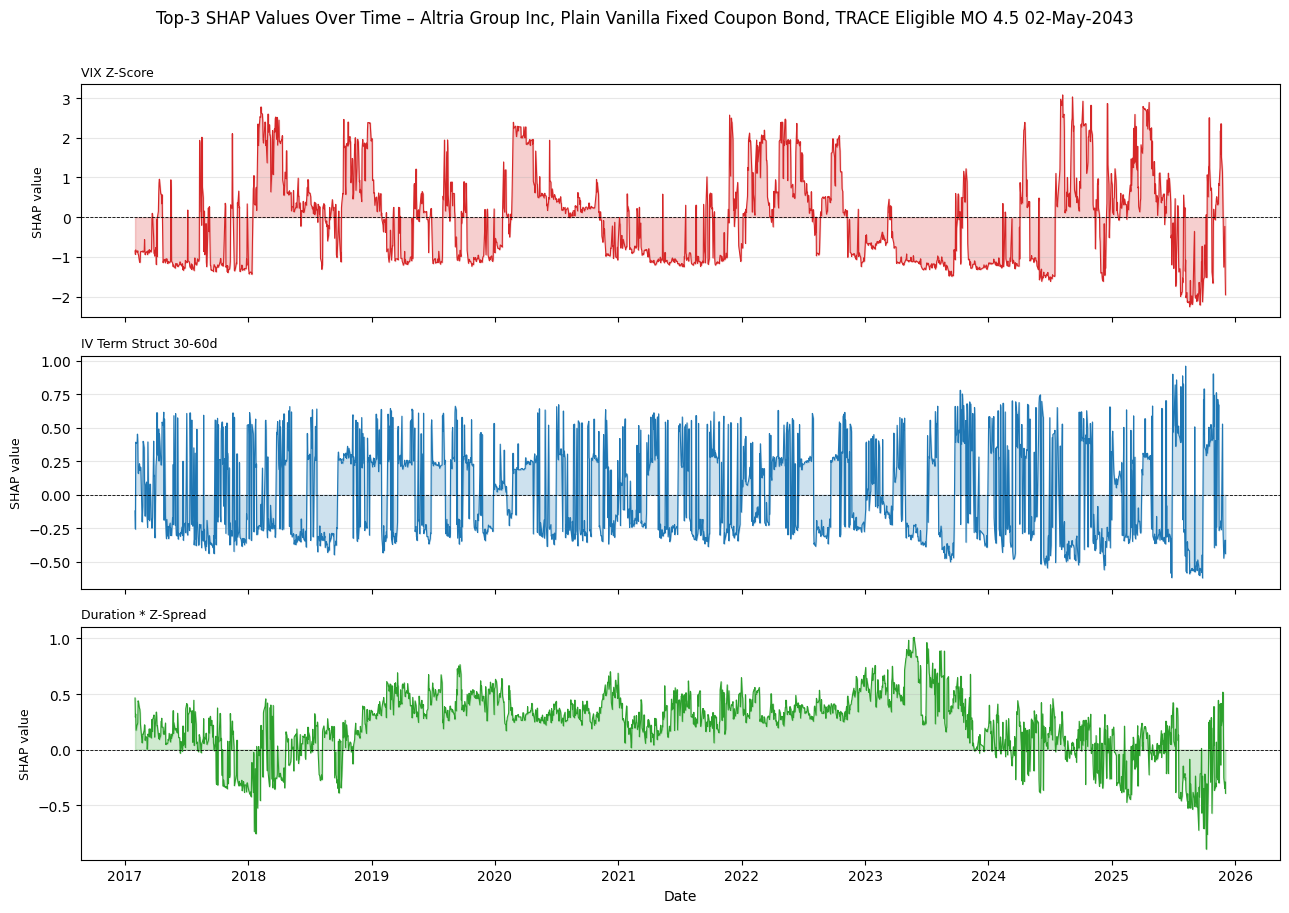

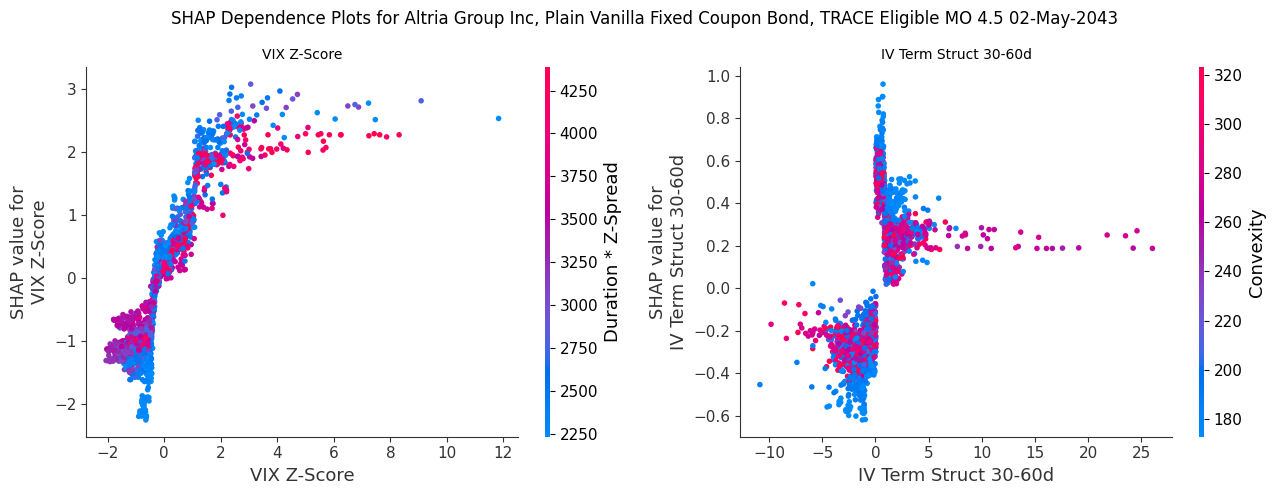

In [37]:
import shap
import numpy as np
import matplotlib.pyplot as plt

best_ric = max(bond_to_pred_power, key=lambda r: np.mean(bond_to_pred_power[r]))
best_bond = ric_to_bond[best_ric]
print(f"Best bond    {best_bond.name}  ({best_ric})")
print(f"Mean hit     {np.mean(bond_to_pred_power[best_ric]):.2%}")
print(f"Fold scores  {['{:.2%}'.format(s) for s in bond_to_pred_power[best_ric]]}")

# ── 2. Re-build X / y for that bond (mirrors the training loop) ──
df = working_dfs[best_ric].copy()

mo_log_move  = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
vix_log_move = np.log(df['VIX_Close'].shift(-30).clip(lower=5)) - np.log(df['VIX_Close'].clip(lower=5))
df['target_residual'] = mo_log_move - vix_log_move

df['dd_velocity_21d']       = df['dd'].diff(21)
df['dd_velocity_5d']        = df['dd'].diff(5)
df['term_structure_30_90']  = df['30D_A_IM_P'] - df['90D_A_IM_P']
df['term_structure_30_60']  = df['30D_A_IM_P'] - df['60D_A_IM_P']
df['vol_30d_velocity']      = df['30D_A_IM_P'].diff(5)
df['vol_zscore']            = (df['30D_A_IM_P'] - df['30D_A_IM_P'].rolling(252).mean()) / df['30D_A_IM_P'].rolling(252).std()
df['leverage_ratio']        = df['Net Debt'] / df['Earnings before Interest Taxes Depreciation & Amortization'].replace(0, np.nan)
df['leverage_velocity_63d'] = df['leverage_ratio'].diff(63)
df['asset_cushion']         = df['Total Assets'] / (df['Short-Term Debt & Current Portion of Long-Term Debt'] + df['Debt - Long-Term - Total']).replace(0, np.nan)
df['dts']                   = df['Modified Duration'] * df['Z Spread']
df['vix_rolling_mean']      = df['VIX_Close'].rolling(252).mean()
df['vix_rolling_std']       = df['VIX_Close'].rolling(252).std()
df['vix_zscore']            = (df['VIX_Close'] - df['vix_rolling_mean']) / df['vix_rolling_std'].replace(0, np.nan)
df['is_negative_equity']    = (df['Price To Book Value Per Share(Time Series Ratio)'] < 0).astype(int)
df['dd_x_neg_equity']       = df['dd'] * df['is_negative_equity']
df = df.drop(columns=['vix_rolling_mean', 'vix_rolling_std'])

feature_cols = [
    'dd', 'dd_velocity_21d', 'term_structure_30_90', 'term_structure_30_60',
    'vol_30d_velocity', 'vol_zscore', 'leverage_ratio', 'leverage_velocity_63d',
    'asset_cushion', 'dts', 'vix_zscore', 'is_negative_equity',
    'Convexity', 'dd_x_neg_equity'
]

FEATURE_LABELS = {
    'dd':                   'Distance-to-Default',
    'dd_velocity_21d':      'DD Velocity (21d)',
    'term_structure_30_90': 'IV Term Struct 30-90d',
    'term_structure_30_60': 'IV Term Struct 30-60d',
    'vol_30d_velocity':     'IV 30d Velocity',
    'vol_zscore':           'IV Z-Score',
    'leverage_ratio':       'Net Debt / EBITDA',
    'leverage_velocity_63d':'Leverage Δ (63d)',
    'asset_cushion':        'Asset Cushion',
    'dts':                  'Duration * Z-Spread',
    'vix_zscore':           'VIX Z-Score',
    'is_negative_equity':   'Negative Equity Flag',
    'Convexity':            'Convexity',
    'dd_x_neg_equity':      'DD * Neg-Equity',
}

y_raw = (df['target_residual'] > 0)
X     = df[feature_cols].dropna()
y     = y_raw.reindex(X.index).dropna().astype(int)
X     = X.reindex(y.index)
X_display = X.rename(columns=FEATURE_LABELS)

from xgboost import XGBClassifier

def get_decay_weights(n, decay_rate=0.005):
    w = np.exp(decay_rate * np.arange(n))
    return w / w.mean()

final_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
final_model.fit(X, y, sample_weight=get_decay_weights(len(X)))
print("Final model fitted on full history.")

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer(X_display)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values, max_display=14, show=False)
plt.title(
    f"SHAP Feature Impact for {best_bond.name}\n"
    "(colour = feature value, x-axis = SHAP log-odds contribution)",
    fontsize=11, pad=12
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
shap.plots.bar(shap_values, max_display=14, show=False)
plt.title(f"Mean abs(SHAP) Feature Importance for {best_bond.name}", fontsize=11, pad=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[-1], max_display=14, show=False)
plt.title(
    f"SHAP Waterfall for Latest obs ({X_display.index[-1].date()}) | {best_bond.name}",
    fontsize=10, pad=12
)
plt.tight_layout()
plt.show()

mean_abs   = np.abs(shap_values.values).mean(axis=0)
top3_idx   = np.argsort(mean_abs)[::-1][:3]
top3_names = [X_display.columns[i] for i in top3_idx]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f"Top-3 SHAP Values Over Time – {best_bond.name}", fontsize=12, y=1.01)

colors = ['#d62728', '#1f77b4', '#2ca02c']
for ax, feat, col in zip(axes, top3_names, colors):
    vals = shap_values[:, feat].values
    ax.fill_between(X_display.index, vals, alpha=0.22, color=col)
    ax.plot(X_display.index, vals, lw=0.8, color=col)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.set_title(feat, fontsize=9, loc='left')
    ax.grid(axis='y', alpha=0.3)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"SHAP Dependence Plots for {best_bond.name}", fontsize=12)
for ax, feat in zip(axes, top3_names[:2]):
    shap.dependence_plot(
        feat, shap_values.values, X_display,
        interaction_index='auto', ax=ax, show=False
    )
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.show()
